In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

from scipy.stats import loguniform
from time import time

df = pd.read_csv("reduced_global_lakes_data.csv")
df.head()

,Unique Lake,Latitude,Longitude,Chla,TP,TN,DO,TSS,Country,Lake Name
0,JPN11042,43.58778,144.53083,0.3,5.0,80.0,9.9,0.27,JPN,Lake Mashu - Deepest Point
1,JPN11048,36.11972,140.39028,56.0,102.0,1800.0,13.7,21.50,JPN,Kasumigaura
2,JPN11041,35.04111,135.89611,12.0,16.0,240.0,9.8,2.00,JPN,Biwa
3,JPN11048,36.04306,140.41167,58.0,117.0,793.0,11.0,21.60,JPN,Kasumigaura
4,JPN11040,35.56778,135.88167,30.0,30.0,750.0,13.0,2.00,JPN,Lake Mikata


In [39]:
print("Initial rows:", len(df))

X = df[['TN','TP']].to_numpy()
y = df['Chla'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1,1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1,1)).ravel()

Initial rows: 400


In [44]:
pipeline = Pipeline([
    ("regress", MLPRegressor(max_iter=5000,random_state=5))
])

# ===============================
# Hyperparameter search space
# ===============================
param_dist = {
    "regress__hidden_layer_sizes":
                    [(i, j, k) for i in range(10, 50) for j in range(10, i+1) for k in range(10, j+1)],
    "regress__solver": ["adam","sgd"],
    "regress__activation": ["relu","tanh","logistic","identity"],
    "regress__alpha": loguniform(1e-3,10)
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=100,
    cv=3,
    scoring="neg_mean_squared_error",
    random_state=1
)

start = time()
random_search.fit(X_train_scaled, y_train_scaled)
print("RandomizedSearchCV took %.2f seconds for %d candidates parameter settings."
        % ((time() - start), n_iter))

print("\nBest Parameters:")
print(random_search.best_params_)

best_model = random_search.best_estimator_

print("\nBest Model:")
print(best_model)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END regress__activation=relu, regress__alpha=6.564847217456313, regress__hidden_layer_sizes=(5,), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=relu, regress__alpha=6.564847217456313, regress__hidden_layer_sizes=(5,), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=relu, regress__alpha=6.564847217456313, regress__hidden_layer_sizes=(5,), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=relu, regress__alpha=6.564847217456313, regress__hidden_layer_sizes=(5,), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=relu, regress__alpha=6.564847217456313, regress__hidden_layer_sizes=(5,), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=relu, regress__alpha=0.14498897332484684, regress__hidden_layer_sizes=(15, 10), regress__solver=sgd; total time=   0.1s
[CV] END regress__activation=relu, regress__alpha=0.14498897332484684

[CV] END regress__activation=tanh, regress__alpha=0.00010451227736204362, regress__hidden_layer_sizes=(20,), regress__solver=sgd; total time=   0.0s
[CV] END regress__activation=tanh, regress__alpha=0.00010451227736204362, regress__hidden_layer_sizes=(20,), regress__solver=sgd; total time=   0.0s
[CV] END regress__activation=tanh, regress__alpha=0.00010451227736204362, regress__hidden_layer_sizes=(20,), regress__solver=sgd; total time=   0.0s
[CV] END regress__activation=relu, regress__alpha=0.8494195203350994, regress__hidden_layer_sizes=(15, 10), regress__solver=sgd; total time=   0.1s
[CV] END regress__activation=relu, regress__alpha=0.8494195203350994, regress__hidden_layer_sizes=(15, 10), regress__solver=sgd; total time=   0.1s
[CV] END regress__activation=relu, regress__alpha=0.8494195203350994, regress__hidden_layer_sizes=(15, 10), regress__solver=sgd; total time=   0.1s
[CV] END regress__activation=relu, regress__alpha=0.8494195203350994, regress__hidden_layer_sizes=(15, 10), r

[CV] END regress__activation=tanh, regress__alpha=0.029136776246569573, regress__hidden_layer_sizes=(15, 10), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=tanh, regress__alpha=0.029136776246569573, regress__hidden_layer_sizes=(15, 10), regress__solver=adam; total time=   0.3s
[CV] END regress__activation=tanh, regress__alpha=0.029136776246569573, regress__hidden_layer_sizes=(15, 10), regress__solver=adam; total time=   0.1s
[CV] END regress__activation=tanh, regress__alpha=0.029136776246569573, regress__hidden_layer_sizes=(15, 10), regress__solver=adam; total time=   0.1s
[CV] END regress__activation=tanh, regress__alpha=0.029136776246569573, regress__hidden_layer_sizes=(15, 10), regress__solver=adam; total time=   0.1s
[CV] END regress__activation=relu, regress__alpha=0.0007338329242316849, regress__hidden_layer_sizes=(5,), regress__solver=adam; total time=   0.1s
[CV] END regress__activation=relu, regress__alpha=0.0007338329242316849, regress__hidden_layer_si

[CV] END regress__activation=tanh, regress__alpha=6.345004539001414, regress__hidden_layer_sizes=(20,), regress__solver=sgd; total time=   0.2s
[CV] END regress__activation=tanh, regress__alpha=6.345004539001414, regress__hidden_layer_sizes=(20,), regress__solver=sgd; total time=   0.2s
[CV] END regress__activation=tanh, regress__alpha=6.345004539001414, regress__hidden_layer_sizes=(20,), regress__solver=sgd; total time=   0.2s
[CV] END regress__activation=tanh, regress__alpha=6.78741352538988, regress__hidden_layer_sizes=(10,), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=tanh, regress__alpha=6.78741352538988, regress__hidden_layer_sizes=(10,), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=tanh, regress__alpha=6.78741352538988, regress__hidden_layer_sizes=(10,), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=tanh, regress__alpha=6.78741352538988, regress__hidden_layer_sizes=(10,), regress__solver=adam; total time=

[CV] END regress__activation=relu, regress__alpha=0.2703138933154518, regress__hidden_layer_sizes=(10,), regress__solver=sgd; total time=   0.1s
[CV] END regress__activation=relu, regress__alpha=0.2703138933154518, regress__hidden_layer_sizes=(10,), regress__solver=sgd; total time=   0.1s
[CV] END regress__activation=tanh, regress__alpha=0.020781356804099746, regress__hidden_layer_sizes=(5,), regress__solver=adam; total time=   0.1s
[CV] END regress__activation=tanh, regress__alpha=0.020781356804099746, regress__hidden_layer_sizes=(5,), regress__solver=adam; total time=   0.1s
[CV] END regress__activation=tanh, regress__alpha=0.020781356804099746, regress__hidden_layer_sizes=(5,), regress__solver=adam; total time=   0.2s
[CV] END regress__activation=tanh, regress__alpha=0.020781356804099746, regress__hidden_layer_sizes=(5,), regress__solver=adam; total time=   0.1s
[CV] END regress__activation=tanh, regress__alpha=0.020781356804099746, regress__hidden_layer_sizes=(5,), regress__solver=

In [45]:

# Predictions
y_train_pred = best_model.predict(X_train_scaled)
y_test_pred = best_model.predict(X_test_scaled)

# Inverse transform
y_train_pred = scaler_y.inverse_transform(y_train_pred.reshape(-1,1))
y_test_pred = scaler_y.inverse_transform(y_test_pred.reshape(-1,1))


In [46]:
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nTraining MSE:", train_mse)
print("Testing MSE:", test_mse)

print("\nTraining R2:", train_r2)
print("Testing R2:", test_r2)


Training MSE: 370.2156452016857
Testing MSE: 426.8927547917207

Training R2: 0.6652753720923736
Testing R2: 0.6446662876143514


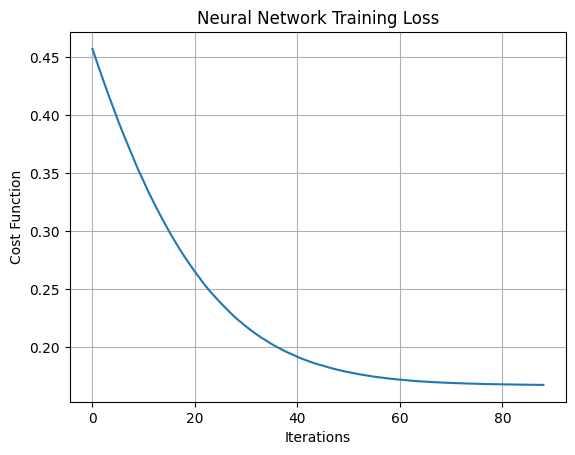

In [47]:
loss_curve = best_model.named_steps["regress"].loss_curve_

plt.figure()
plt.plot(loss_curve)
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.title("Neural Network Training Loss")
plt.grid()
plt.show()